<a href="https://colab.research.google.com/github/daaastis/fundamentals-of-data-mining/blob/main/%D0%A0%D0%B0%D0%B7%D0%B4%D0%B5%D0%BB%D0%B8%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D0%B0%D1%8F_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 ЭТАП 1: ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ CUSTOMERS 
[Успешно] Загружено объектов: 500, признаков: 2

 ЭТАП 2: ЭКСПЕРИМЕНТЫ С ПАРАМЕТРОМ K (ОШИБКА КЛАСТЕРИЗАЦИИ) 


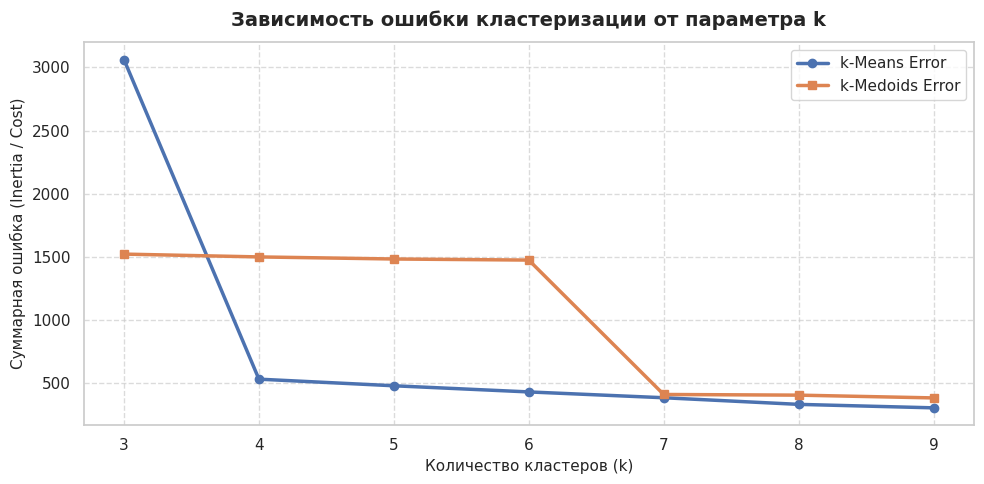

 ЭТАП 3: ЭКСПЕРИМЕНТЫ С ВАРЬИРОВАНИЕМ ДОЛИ ШУМА 


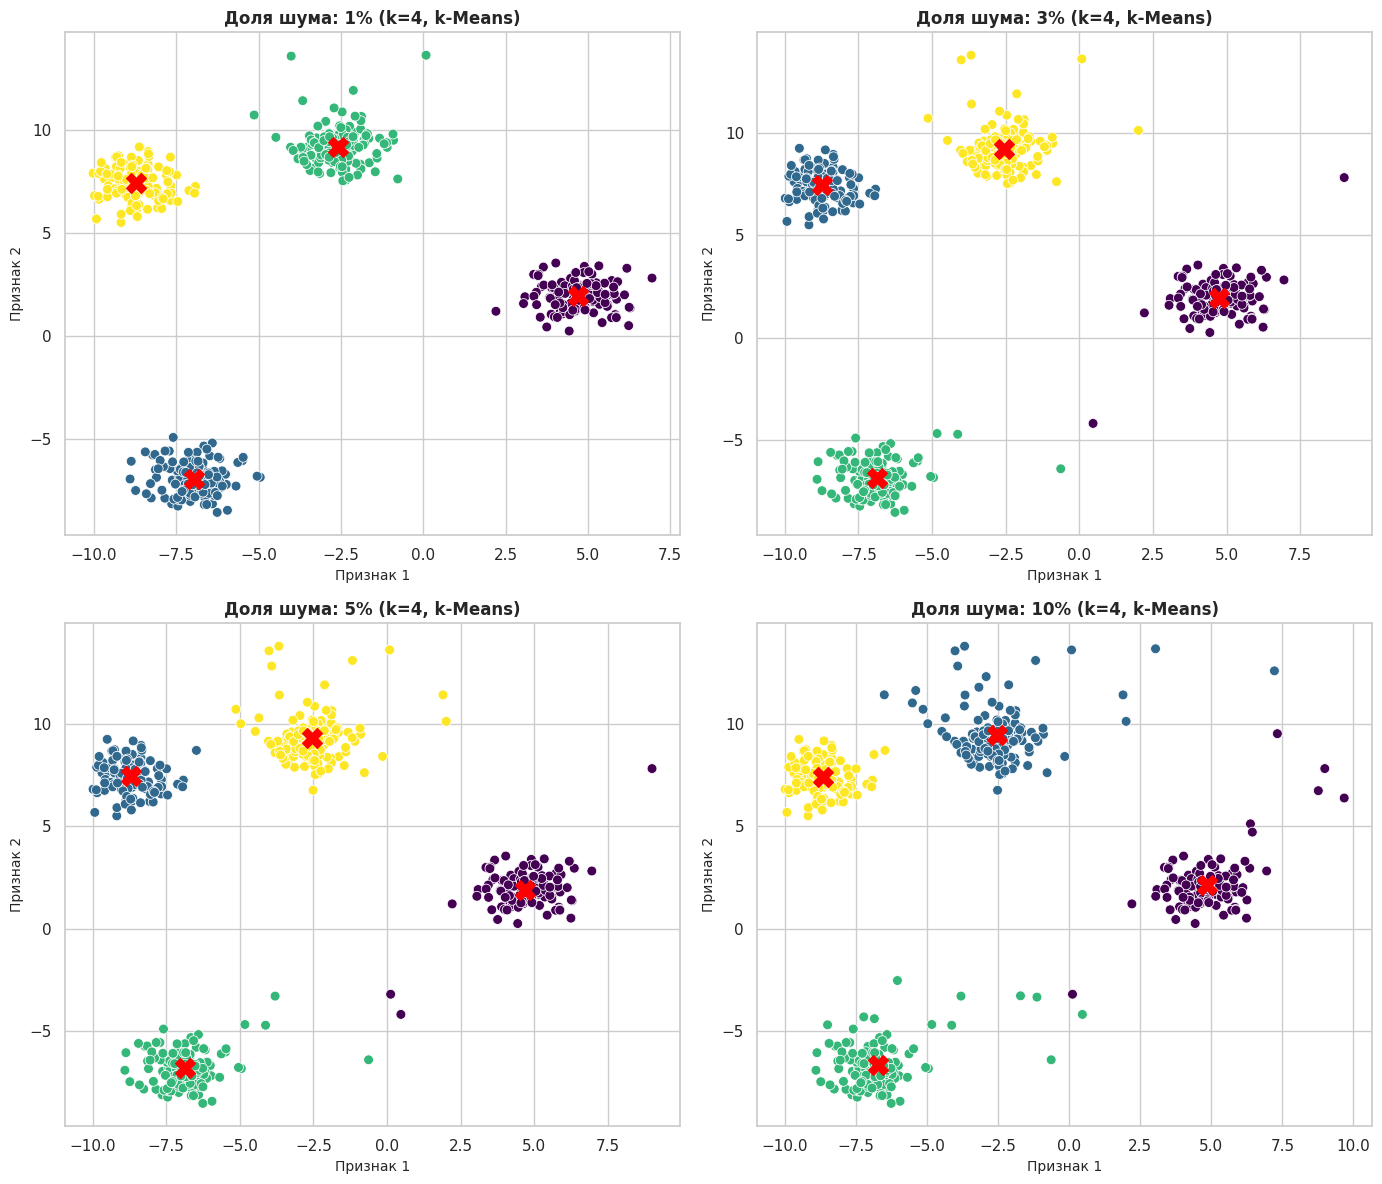

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

# Установка tabulate для красивого вывода таблиц
!pip install tabulate -q
from tabulate import tabulate

print("=" * 70)
print(" ЭТАП 1: ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ CUSTOMERS ")
print("=" * 70)

dataset_filename = 'customers.csv'

df = pd.read_csv(dataset_filename)
X_original = df.values
print(f"[Успешно] Загружено объектов: {X_original.shape[0]}, признаков: {X_original.shape[1]}\n")


# =================================================================
# 2. РЕАЛИЗАЦИЯ АЛГОРИТМА K-MEDOIDS (КЛАСС)
# =================================================================
class KMedoids:
    def __init__(self, n_clusters=3, max_iter=300, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.cluster_centers_ = None
        self.labels_ = None
        self.inertia_ = 0.0

    def fit(self, X):
        np.random.seed(self.random_state)
        n_samples = X.shape[0]

        # Случайный выбор начальных медоидов
        medoid_indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.cluster_centers_ = X[medoid_indices]

        for _ in range(self.max_iter):
            # Расстояние от каждой точки до медоидов (евклидово)
            distances = np.linalg.norm(X[:, np.newaxis, :] - self.cluster_centers_[np.newaxis, :, :], axis=2)
            self.labels_ = np.argmin(distances, axis=1)

            new_medoid_indices = np.zeros(self.n_clusters, dtype=int)
            for k in range(self.n_clusters):
                cluster_members = np.where(self.labels_ == k)[0]
                if len(cluster_members) == 0:
                    new_medoid_indices[k] = medoid_indices[k]
                    continue
                # Находим точку внутри кластера с минимальной суммой расстояний до остальных
                cluster_points = X[cluster_members]
                d_matrix = np.linalg.norm(cluster_points[:, np.newaxis, :] - cluster_points[np.newaxis, :, :], axis=2)
                sum_dists = np.sum(d_matrix, axis=1)
                best_idx = cluster_members[np.argmin(sum_dists)]
                new_medoid_indices[k] = best_idx

            if np.all(new_medoid_indices == medoid_indices):
                break
            medoid_indices = new_medoid_indices
            self.cluster_centers_ = X[medoid_indices]

        # Расчет суммарной ошибки кластеризации (inertia)
        final_distances = np.linalg.norm(X[:, np.newaxis, :] - self.cluster_centers_[np.newaxis, :, :], axis=2)
        self.inertia_ = np.sum(np.min(final_distances, axis=1))
        return self


# =================================================================
# 3. ФУНКЦИЯ ДОБАВЛЕНИЯ ШУМА
# =================================================================
def add_noise(X, noise_ratio):
    if noise_ratio == 0:
        return X.copy()
    X_noisy = X.copy()
    n_samples, n_features = X_noisy.shape
    n_noisy = int(n_samples * noise_ratio)

    np.random.seed(42)
    noisy_indices = np.random.choice(n_samples, n_noisy, replace=False)

    # Добавление случайного смещения к координатам зашумленных объектов
    noise = np.random.normal(loc=3.0, scale=2.0, size=(n_noisy, n_features))
    X_noisy[noisy_indices] += noise
    return X_noisy


# =================================================================
# 4. ЭКСПЕРИМЕНТЫ И ВИЗУАЛИЗАЦИЯ ПРИ ИЗМЕНЯЕМОМ КРИТЕРИИ K
# =================================================================
print("=" * 70)
print(" ЭТАП 2: ЭКСПЕРИМЕНТЫ С ПАРАМЕТРОМ K (ОШИБКА КЛАСТЕРИЗАЦИИ) ")
print("=" * 70)

k_values = list(range(3, 10))
kmeans_errors = []
kmedoids_errors = []

for k in k_values:
    # k-Means
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_original)
    kmeans_errors.append(km.inertia_)

    # k-Medoids
    kmd = KMedoids(n_clusters=k, random_state=42)
    kmd.fit(X_original)
    kmedoids_errors.append(kmd.inertia_)

# График зависимости ошибки от k
plt.figure(figsize=(10, 5))
plt.plot(k_values, kmeans_errors, marker='o', label='k-Means Error', linewidth=2.5)
plt.plot(k_values, kmedoids_errors, marker='s', label='k-Medoids Error', linewidth=2.5)
plt.title("Зависимость ошибки кластеризации от параметра k", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Количество кластеров (k)", fontsize=11)
plt.ylabel("Суммарная ошибка (Inertia / Cost)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


# =================================================================
# 5. ЭКСПЕРИМЕНТЫ С ШУМОМ И ВИЗУАЛИЗАЦИЯ ТОЧЕЧНЫХ ГРАФИКОВ
# =================================================================
print("=" * 70)
print(" ЭТАП 3: ЭКСПЕРИМЕНТЫ С ВАРЬИРОВАНИЕМ ДОЛИ ШУМА ")
print("=" * 70)

noise_levels = [0.01, 0.03, 0.05, 0.10] # 1%, 3%, 5%, 10%
chosen_k = 4

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, noise in enumerate(noise_levels):
    X_noisy = add_noise(X_original, noise)

    # Кластеризация k-Means на зашумленных данных
    km = KMeans(n_clusters=chosen_k, n_init=10, random_state=42)
    labels = km.fit_predict(X_noisy)
    centers = km.cluster_centers_

    # Точечный график
    sns.scatterplot(x=X_noisy[:, 0], y=X_noisy[:, 1], hue=labels, palette='viridis', ax=axes[idx], s=50, legend=False)
    axes[idx].scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Центроиды')
    axes[idx].set_title(f"Доля шума: {int(noise*100)}% (k={chosen_k}, k-Means)", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Признак 1", fontsize=10)
    axes[idx].set_ylabel("Признак 2", fontsize=10)

plt.tight_layout()
plt.show()